### 181 - Multivariate time series forecasting using LSTM

https://www.youtube.com/watch?v=tepxdcepTbY

https://github.com/bnsreenu/python_for_microscopists/blob/master/

https://github.com/bnsreenu/python_for_microscopists/blob/master/181_multivariate_timeseries_LSTM_GE.py

https://www.kaggle.com/datasets/vaibhavshankhwar/ge-aerospace-dataset/data

https://www.kaggle.com/datasets/aniketkolte04/ge-stock-price

In [47]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from datetime import datetime

In [48]:
#Read the csv file
df = pd.read_csv('GE_completo.csv')
print(df.head()) #7 columns, including the Date. 


         Date      Open      High       Low     Close  Volume
0  02-01-1962  0.789087  0.802238  0.781196  0.786456  345317
1  03-01-1962  0.782510  0.782510  0.775935  0.778565  236606
2  04-01-1962  0.778565  0.785140  0.762783  0.769359  294159
3  05-01-1962  0.769359  0.770674  0.736480  0.749632  436442
4  08-01-1962  0.749632  0.749632  0.725960  0.748317  495593


In [49]:
print(df.tail()) #7 columns, including the Date. 


             Date       Open       High        Low      Close   Volume
15383  10-02-2023  80.809998  81.349998  80.400002  81.290001  3490100
15384  13-02-2023  81.199997  82.919998  81.080002  82.680000  4081600
15385  14-02-2023  82.129997  83.809998  81.959999  83.540001  5368500
15386  15-02-2023  82.610001  84.790001  82.440002  84.769997  5831400
15387  16-02-2023  83.610001  84.535004  82.975899  84.050003  3728232


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15388 entries, 0 to 15387
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    15388 non-null  object 
 1   Open    15388 non-null  float64
 2   High    15388 non-null  float64
 3   Low     15388 non-null  float64
 4   Close   15388 non-null  float64
 5   Volume  15388 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 721.4+ KB


In [51]:
df['Date'].unique()

array(['02-01-1962', '03-01-1962', '04-01-1962', ..., '14-02-2023',
       '15-02-2023', '16-02-2023'], dtype=object)

In [52]:
#Separate dates for future plotting
train_dates = pd.to_datetime(df['Date'], format="%d-%m-%Y", errors='raise')


In [53]:

print(train_dates.tail(15)) #Check last few dates. 

15373   2023-01-27
15374   2023-01-30
15375   2023-01-31
15376   2023-02-01
15377   2023-02-02
15378   2023-02-03
15379   2023-02-06
15380   2023-02-07
15381   2023-02-08
15382   2023-02-09
15383   2023-02-10
15384   2023-02-13
15385   2023-02-14
15386   2023-02-15
15387   2023-02-16
Name: Date, dtype: datetime64[ns]


In [54]:
#Variables for training
cols = list(df)[1:6]
#Date and volume columns are not used in training. 
print(cols) #['Open', 'High', 'Low', 'Close', 'Adj Close']

['Open', 'High', 'Low', 'Close', 'Volume']


In [55]:
# tamanho do arquivo
len(df)

15388

In [56]:
#New dataframe with only training data - 5 columns
df_for_training = df[cols].astype(float)


<Axes: >

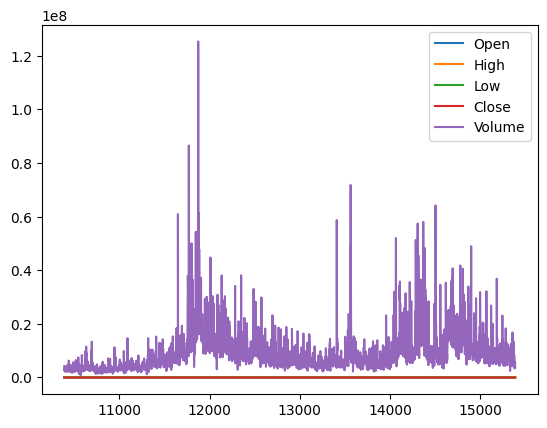

In [57]:
df_for_plot=df_for_training.tail(5000)
df_for_plot.plot.line() # plotagem curiosa.

In [58]:
#LSTM uses sigmoid and tanh that are sensitive to magnitude so values need to be normalized
# normalize the dataset
scaler = StandardScaler()
scaler = scaler.fit(df_for_training)
df_for_training_scaled = scaler.transform(df_for_training)
# transformar várias colunas em uma

In [59]:
scaler

StandardScaler()

In [60]:
df_for_training_scaled[:20]

array([[-0.88756008, -0.88814305, -0.88667498, -0.8874634 , -0.68184691],
       [-0.88767871, -0.88849549, -0.88677087, -0.88760576, -0.70161816],
       [-0.88774989, -0.8884485 , -0.88701057, -0.88777185, -0.69115101],
       [-0.88791596, -0.88870694, -0.88748996, -0.88812772, -0.66527403],
       [-0.88827182, -0.88908285, -0.88768171, -0.88815145, -0.65451625],
       [-0.88829555, -0.8889184 , -0.88737011, -0.88808028, -0.67690424],
       [-0.88822438, -0.8888949 , -0.88725026, -0.8880091 , -0.68766202],
       [-0.88815319, -0.88894188, -0.8873701 , -0.88798536, -0.69725692],
       [-0.88812948, -0.8889184 , -0.88734614, -0.88817518, -0.69551243],
       [-0.88829555, -0.88894189, -0.88727423, -0.88803283, -0.68300997],
       [-0.88817693, -0.88882442, -0.88725027, -0.8879142 , -0.7042349 ],
       [-0.88808203, -0.8888949 , -0.88744202, -0.88822263, -0.68242853],
       [-0.88836672, -0.88903587, -0.88737011, -0.88808028, -0.70161816],
       [-0.88822436, -0.88891838, -0.8

In [61]:

#As required for LSTM networks, we require to reshape an input data into n_samples x timesteps x n_features. 
#In this example, the n_features is 5. We will make timesteps = 14 (past days data used for training). 

#Empty lists to be populated using formatted training data
trainX = []
trainY = []

n_future = 1   # Number of days we want to look into the future based on the past days. # dias
n_past = 14  # Number of past days we want to use to predict the future.  # semanas que desejo ver

In [62]:

#Reformat input data into a shape: (n_samples x timesteps x n_features)
#In my example, my df_for_training_scaled has a shape (12823, 5)
#12823 refers to the number of data points and 5 refers to the columns (multi-variables).
for i in range(n_past, len(df_for_training_scaled) - n_future +1):
    trainX.append(df_for_training_scaled[i - n_past:i, 0:df_for_training.shape[1]])
    trainY.append(df_for_training_scaled[i + n_future - 1:i + n_future, 0])


In [63]:
trainX, trainY = np.array(trainX), np.array(trainY)


In [64]:
trainX[:15]

array([[[-0.88756008, -0.88814305, -0.88667498, -0.8874634 ,
         -0.68184691],
        [-0.88767871, -0.88849549, -0.88677087, -0.88760576,
         -0.70161816],
        [-0.88774989, -0.8884485 , -0.88701057, -0.88777185,
         -0.69115101],
        ...,
        [-0.88808203, -0.8888949 , -0.88744202, -0.88822263,
         -0.68242853],
        [-0.88836672, -0.88903587, -0.88737011, -0.88808028,
         -0.70161816],
        [-0.88822436, -0.88891838, -0.88720231, -0.88796164,
         -0.70597939]],

       [[-0.88767871, -0.88849549, -0.88677087, -0.88760576,
         -0.70161816],
        [-0.88774989, -0.8884485 , -0.88701057, -0.88777185,
         -0.69115101],
        [-0.88791596, -0.88870694, -0.88748996, -0.88812772,
         -0.66527403],
        ...,
        [-0.88836672, -0.88903587, -0.88737011, -0.88808028,
         -0.70161816],
        [-0.88822436, -0.88891838, -0.88720231, -0.88796164,
         -0.70597939],
        [-0.88808203, -0.88870695, -0.88705851, 

In [65]:
trainY[:15]

array([[-0.88808203],
       [-0.88810576],
       [-0.88831928],
       [-0.8880583 ],
       [-0.88820064],
       [-0.8882481 ],
       [-0.8880583 ],
       [-0.88798714],
       [-0.88756008],
       [-0.887655  ],
       [-0.88760754],
       [-0.88779733],
       [-0.88770244],
       [-0.88756009],
       [-0.88746519]])

In [66]:
df_for_training_scaled[:15]

array([[-0.88756008, -0.88814305, -0.88667498, -0.8874634 , -0.68184691],
       [-0.88767871, -0.88849549, -0.88677087, -0.88760576, -0.70161816],
       [-0.88774989, -0.8884485 , -0.88701057, -0.88777185, -0.69115101],
       [-0.88791596, -0.88870694, -0.88748996, -0.88812772, -0.66527403],
       [-0.88827182, -0.88908285, -0.88768171, -0.88815145, -0.65451625],
       [-0.88829555, -0.8889184 , -0.88737011, -0.88808028, -0.67690424],
       [-0.88822438, -0.8888949 , -0.88725026, -0.8880091 , -0.68766202],
       [-0.88815319, -0.88894188, -0.8873701 , -0.88798536, -0.69725692],
       [-0.88812948, -0.8889184 , -0.88734614, -0.88817518, -0.69551243],
       [-0.88829555, -0.88894189, -0.88727423, -0.88803283, -0.68300997],
       [-0.88817693, -0.88882442, -0.88725027, -0.8879142 , -0.7042349 ],
       [-0.88808203, -0.8888949 , -0.88744202, -0.88822263, -0.68242853],
       [-0.88836672, -0.88903587, -0.88737011, -0.88808028, -0.70161816],
       [-0.88822436, -0.88891838, -0.8

In [67]:
# prevê o 15 dia

In [68]:
print('trainX shape == {}.'.format(trainX.shape))
print('trainY shape == {}.'.format(trainY.shape))

trainX shape == (15374, 14, 5).
trainY shape == (15374, 1).


In [69]:

#In my case, trainX has a shape (12809, 14, 5). 
#12809 because we are looking back 14 days (12823 - 14 = 12809). 
#Remember that we cannot look back 14 days until we get to the 15th day. 
#Also, trainY has a shape (12809, 1). Our model only predicts a single value, but 
#it needs multiple variables (5 in my example) to make this prediction. 
#This is why we can only predict a single day after our training, the day after where our data ends.
#To predict more days in future, we need all the 5 variables which we do not have. 
#We need to predict all variables if we want to do that. 

# define the Autoencoder model

model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(trainX.shape[1], trainX.shape[2]), return_sequences=True))
model.add(LSTM(32, activation='relu', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(trainY.shape[1]))

/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [70]:
model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 14, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:

# fit the model
history = model.fit(trainX, trainY, epochs=5, batch_size=16, validation_split=0.1, verbose=1)



Epoch 1/5
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0874 - val_loss: 0.0039
Epoch 2/5
865/865 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0266 - val_loss: 0.0038
Epoch 3/5
865/865 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0271 - val_loss: 0.0040
Epoch 4/5
865/865 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0248 - val_loss: 0.0031
Epoch 5/5
865/865 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0236 - val_loss: 0.0093


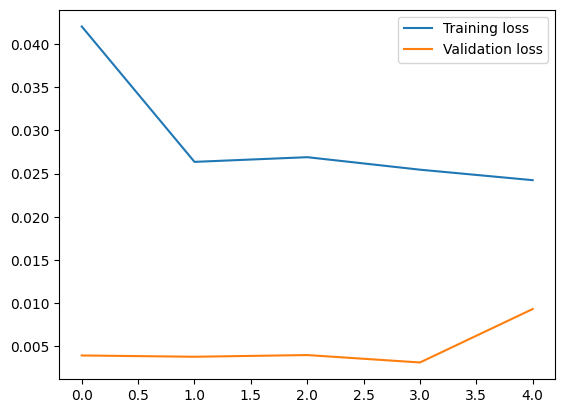

In [72]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

# quero prever agora para mais dias 

In [73]:
#Predicting...
#Libraries that will help us extract only business days in the US.
#Otherwise our dates would be wrong when we look back (or forward).  
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
#Remember that we can only predict one day in future as our model needs 5 variables
#as inputs for prediction. We only have all 5 variables until the last day in our dataset.

In [75]:
#Remember that we can only predict one day in future as our model needs 5 variables
#as inputs for prediction. We only have all 5 variables until the last day in our dataset.
n_future= 90
forecast_period_dates = pd.date_range(list(train_dates)[-1], periods=n_future, freq='1d').tolist()
print(forecast_period_dates)


[Timestamp('2023-02-16 00:00:00'), Timestamp('2023-02-17 00:00:00'), Timestamp('2023-02-18 00:00:00'), Timestamp('2023-02-19 00:00:00'), Timestamp('2023-02-20 00:00:00'), Timestamp('2023-02-21 00:00:00'), Timestamp('2023-02-22 00:00:00'), Timestamp('2023-02-23 00:00:00'), Timestamp('2023-02-24 00:00:00'), Timestamp('2023-02-25 00:00:00'), Timestamp('2023-02-26 00:00:00'), Timestamp('2023-02-27 00:00:00'), Timestamp('2023-02-28 00:00:00'), Timestamp('2023-03-01 00:00:00'), Timestamp('2023-03-02 00:00:00'), Timestamp('2023-03-03 00:00:00'), Timestamp('2023-03-04 00:00:00'), Timestamp('2023-03-05 00:00:00'), Timestamp('2023-03-06 00:00:00'), Timestamp('2023-03-07 00:00:00'), Timestamp('2023-03-08 00:00:00'), Timestamp('2023-03-09 00:00:00'), Timestamp('2023-03-10 00:00:00'), Timestamp('2023-03-11 00:00:00'), Timestamp('2023-03-12 00:00:00'), Timestamp('2023-03-13 00:00:00'), Timestamp('2023-03-14 00:00:00'), Timestamp('2023-03-15 00:00:00'), Timestamp('2023-03-16 00:00:00'), Timestamp('20

In [76]:
#forecast 
forecast  = model.predict(trainX[-n_future:]) 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [77]:
forecast

array([[0.01427951],
       [0.01657223],
       [0.01671513],
       [0.01605123],
       [0.0149725 ],
       [0.01798346],
       [0.02473619],
       [0.03354748],
       [0.04205345],
       [0.04955625],
       [0.05717295],
       [0.06664752],
       [0.07524531],
       [0.08546107],
       [0.09821435],
       [0.11198246],
       [0.12499853],
       [0.13710415],
       [0.14601165],
       [0.1519838 ],
       [0.16124141],
       [0.17337188],
       [0.1876331 ],
       [0.20075321],
       [0.21422893],
       [0.22760284],
       [0.23973161],
       [0.25123692],
       [0.25901362],
       [0.26189852],
       [0.265742  ],
       [0.26804602],
       [0.27188858],
       [0.27695036],
       [0.283289  ],
       [0.28511694],
       [0.28358704],
       [0.27938104],
       [0.2771294 ],
       [0.27510053],
       [0.27271903],
       [0.2708811 ],
       [0.2688052 ],
       [0.26492816],
       [0.2578404 ],
       [0.2508556 ],
       [0.24589002],
       [0.240

In [78]:
#Perform inverse transformation to rescale back to original range
#Since we used 5 variables for transform, the inverse expects same dimensions
#Therefore, let us copy our values 5 times and discard them after inverse transform
forecast_copies = np.repeat(forecast, df_for_training.shape[1], axis=-1)
y_pred_future = scaler.inverse_transform(forecast_copies)[:,0]

In [79]:
y_pred_future

array([50.781715, 50.90881 , 50.91673 , 50.87993 , 50.82013 , 50.987038,
       51.36137 , 51.849815, 52.321335, 52.737247, 53.15947 , 53.684685,
       54.161297, 54.727596, 55.434563, 56.197784, 56.91932 , 57.59038 ,
       58.08416 , 58.415222, 58.92841 , 59.60085 , 60.391407, 61.11871 ,
       61.865723, 62.607094, 63.279438, 63.917225, 64.34832 , 64.50824 ,
       64.7213  , 64.84902 , 65.06203 , 65.34263 , 65.694   , 65.795334,
       65.710526, 65.47737 , 65.352554, 65.24008 , 65.10806 , 65.00618 ,
       64.891106, 64.676186, 64.28328 , 63.896088, 63.620827, 63.296318,
       62.748245, 62.00485 , 61.417473, 61.000706, 60.993866, 61.092316,
       61.307373, 61.60119 , 61.876625, 62.1673  , 62.481087, 62.816734,
       63.441925, 64.3676  , 65.41566 , 66.50645 , 67.601555, 68.90956 ,
       70.26782 , 71.63021 , 72.92197 , 73.984   , 74.3489  , 74.47387 ,
       74.680916, 74.88902 , 75.28671 , 75.84326 , 76.51041 , 77.05143 ,
       77.224144, 77.431496, 77.82975 , 78.21053 , 

In [80]:
forecast_copies

array([[0.01427951, 0.01427951, 0.01427951, 0.01427951, 0.01427951],
       [0.01657223, 0.01657223, 0.01657223, 0.01657223, 0.01657223],
       [0.01671513, 0.01671513, 0.01671513, 0.01671513, 0.01671513],
       [0.01605123, 0.01605123, 0.01605123, 0.01605123, 0.01605123],
       [0.0149725 , 0.0149725 , 0.0149725 , 0.0149725 , 0.0149725 ],
       [0.01798346, 0.01798346, 0.01798346, 0.01798346, 0.01798346],
       [0.02473619, 0.02473619, 0.02473619, 0.02473619, 0.02473619],
       [0.03354748, 0.03354748, 0.03354748, 0.03354748, 0.03354748],
       [0.04205345, 0.04205345, 0.04205345, 0.04205345, 0.04205345],
       [0.04955625, 0.04955625, 0.04955625, 0.04955625, 0.04955625],
       [0.05717295, 0.05717295, 0.05717295, 0.05717295, 0.05717295],
       [0.06664752, 0.06664752, 0.06664752, 0.06664752, 0.06664752],
       [0.07524531, 0.07524531, 0.07524531, 0.07524531, 0.07524531],
       [0.08546107, 0.08546107, 0.08546107, 0.08546107, 0.08546107],
       [0.09821435, 0.09821435, 0.

In [84]:
# Convert timestamp to date
forecast_dates = []
for time_i in forecast_period_dates:
    forecast_dates.append(time_i.date())
    
df_forecast = pd.DataFrame({'Date':np.array(forecast_dates), 'Open':y_pred_future})
df_forecast['Date']=pd.to_datetime(df_forecast['Date'])
df_forecast # Forecast for 90 days or A 90-day projectio

,Date,Open
0,2023-02-16,50.781715
1,2023-02-17,50.908810
2,2023-02-18,50.916729
3,2023-02-19,50.879929
4,2023-02-20,50.820129
...,...,...
85,2023-05-12,78.850304
86,2023-05-13,78.780579
87,2023-05-14,78.835075
88,2023-05-15,78.998665


In [99]:
original = df[['Date', 'Open']]
original['Date'] = pd.to_datetime(original['Date'], format="%d-%m-%Y", errors='raise')

/tmp/ipykernel_5855/2162506387.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  original['Date'] = pd.to_datetime(original['Date'], format="%d-%m-%Y", errors='raise')


In [100]:
original

,Date,Open
0,1962-01-02,0.789087
1,1962-01-03,0.782510
2,1962-01-04,0.778565
3,1962-01-05,0.769359
4,1962-01-08,0.749632
...,...,...
15383,2023-02-10,80.809998
15384,2023-02-13,81.199997
15385,2023-02-14,82.129997
15386,2023-02-15,82.610001


In [102]:


#original['Date']=pd.to_datetime(original['Date'])
original = original.loc[original['Date'] >= '2020-5-1']

In [103]:
df_forecast

,Date,Open
0,2023-02-16,50.781715
1,2023-02-17,50.908810
2,2023-02-18,50.916729
3,2023-02-19,50.879929
4,2023-02-20,50.820129
...,...,...
85,2023-05-12,78.850304
86,2023-05-13,78.780579
87,2023-05-14,78.835075
88,2023-05-15,78.998665


<Axes: xlabel='Date', ylabel='Open'>

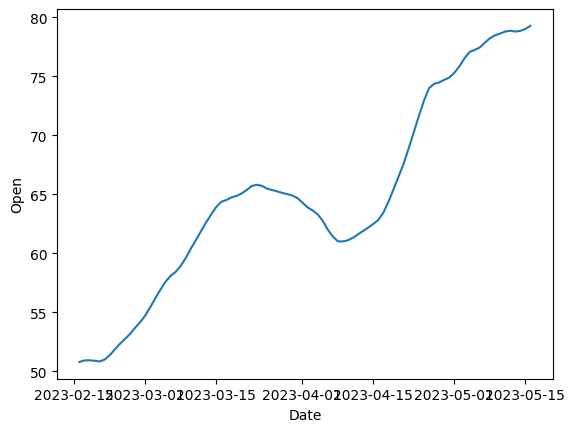

In [104]:
sns.lineplot(x=df_forecast['Date'], y=df_forecast['Open'])


<Axes: xlabel='Date', ylabel='Open'>

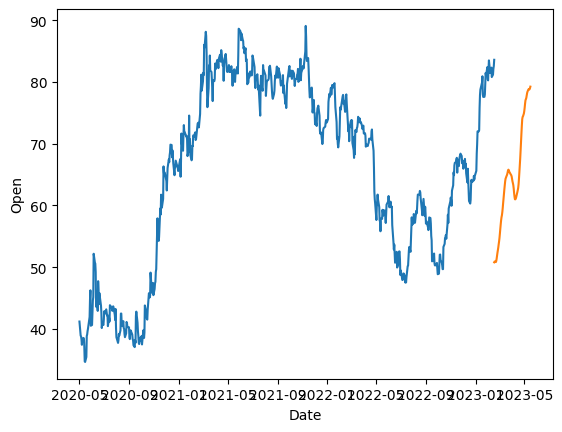

In [105]:
sns.lineplot(x=original['Date'], y=original['Open'])
sns.lineplot(x=df_forecast['Date'], y=df_forecast['Open'])


[Timestamp('2023-01-26 00:00:00'), Timestamp('2023-01-27 00:00:00'), Timestamp('2023-01-30 00:00:00'), Timestamp('2023-01-31 00:00:00'), Timestamp('2023-02-01 00:00:00'), Timestamp('2023-02-02 00:00:00'), Timestamp('2023-02-03 00:00:00'), Timestamp('2023-02-06 00:00:00'), Timestamp('2023-02-07 00:00:00'), Timestamp('2023-02-08 00:00:00'), Timestamp('2023-02-09 00:00:00'), Timestamp('2023-02-10 00:00:00'), Timestamp('2023-02-13 00:00:00'), Timestamp('2023-02-14 00:00:00'), Timestamp('2023-02-15 00:00:00')]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/tmp/ipykernel_5855/2053392678.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  original['Date'] = pd.to_datetime(original['Date'], format="%d-%m-%Y", errors='raise')


<Axes: xlabel='Date', ylabel='Open'>

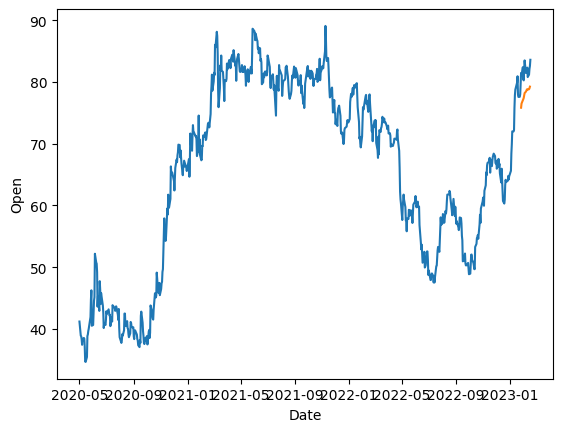

In [107]:
#Predicting...
#Libraries that will help us extract only business days in the US.
#Otherwise our dates would be wrong when we look back (or forward).  
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
#Remember that we can only predict one day in future as our model needs 5 variables
#as inputs for prediction. We only have all 5 variables until the last day in our dataset.
n_past = 16
n_days_for_prediction=15  #let us predict past 15 days

predict_period_dates = pd.date_range(list(train_dates)[-n_past], periods=n_days_for_prediction, freq=us_bd).tolist()
print(predict_period_dates)

#Make prediction
prediction = model.predict(trainX[-n_days_for_prediction:]) #shape = (n, 1) where n is the n_days_for_prediction

#Perform inverse transformation to rescale back to original range
#Since we used 5 variables for transform, the inverse expects same dimensions
#Therefore, let us copy our values 5 times and discard them after inverse transform
prediction_copies = np.repeat(prediction, df_for_training.shape[1], axis=-1)
y_pred_future = scaler.inverse_transform(prediction_copies)[:,0]


# Convert timestamp to date
forecast_dates = []
for time_i in predict_period_dates:
    forecast_dates.append(time_i.date())
    
df_forecast = pd.DataFrame({'Date':np.array(forecast_dates), 'Open':y_pred_future})
df_forecast['Date']=pd.to_datetime(df_forecast['Date'])


original = df[['Date', 'Open']]
original['Date'] = pd.to_datetime(original['Date'], format="%d-%m-%Y", errors='raise')
original = original.loc[original['Date'] >= '2020-5-1']

sns.lineplot(x=original['Date'], y=original['Open'])
sns.lineplot(x=df_forecast['Date'], y=df_forecast['Open'])